# SupplyShield AI — Anomaly Detection ML

**Member 2 | Machine Learning & Risk Intelligence**

This notebook develops an unsupervised anomaly-detection pipeline for identifying unusual supply-chain and marketplace observations.

The model uses engineered market, price, availability, supplier, source, review, NLP-oriented, and data-quality signals generated by the previous feature-engineering stage.

Because the current dataset does not contain verified ground-truth anomaly labels, model evaluation focuses on unsupervised diagnostics, anomaly-score distributions, stability, and business interpretability rather than fabricated classification accuracy.

In [1]:
# ============================================================
# SUPPLYSHIELD AI
# MEMBER 2 — ANOMALY DETECTION ML
# ENVIRONMENT & DEPENDENCIES
# ============================================================

from __future__ import annotations

import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

RANDOM_STATE = 42

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("=" * 80)
print("SUPPLYSHIELD AI — ANOMALY DETECTION ML")
print("=" * 80)

print("Environment initialized successfully.")
print(f"Random state: {RANDOM_STATE}")

SUPPLYSHIELD AI — ANOMALY DETECTION ML
Environment initialized successfully.
Random state: 42


In [2]:
# ============================================================
# PROJECT & ARTIFACT DISCOVERY
# ============================================================

PROJECT_ROOT = Path.cwd().resolve()

# Notebook location:
# SupplyShield-AI/member2/notebooks/
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

# Additional fallback
if not (PROJECT_ROOT / "member2").exists():

    for parent in [Path.cwd(), *Path.cwd().parents]:

        if (parent / "member2").exists():
            PROJECT_ROOT = parent
            break


FEATURE_DIR = (
    PROJECT_ROOT
    / "member2"
    / "outputs"
    / "feature_engineering"
)

FEATURE_DATASET_PATH = (
    FEATURE_DIR
    / "supplyshield_feature_dataset.csv"
)

FEATURE_LIST_PATH = (
    FEATURE_DIR
    / "ml_feature_list.json"
)

MODEL_OUTPUT_DIR = (
    PROJECT_ROOT
    / "member2"
    / "outputs"
    / "models"
)

ML_OUTPUT_DIR = (
    PROJECT_ROOT
    / "member2"
    / "outputs"
    / "ml_results"
)

FIGURE_OUTPUT_DIR = (
    PROJECT_ROOT
    / "member2"
    / "outputs"
    / "ml_figures"
)

MODEL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

ML_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:")
print(PROJECT_ROOT)

print("\nFeature dataset:")
print(FEATURE_DATASET_PATH)

print("\nModel output:")
print(MODEL_OUTPUT_DIR)

print("\nML output:")
print(ML_OUTPUT_DIR)

print("\nFigure output:")
print(FIGURE_OUTPUT_DIR)

if not FEATURE_DATASET_PATH.exists():
    raise FileNotFoundError(
        "Feature dataset not found. "
        "Run 02_feature_engineering.ipynb first."
    )

if not FEATURE_LIST_PATH.exists():
    raise FileNotFoundError(
        "ML feature list not found. "
        "Run 02_feature_engineering.ipynb first."
    )

print("\nAll required artifacts found.")

Project root:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI

Feature dataset:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\feature_engineering\supplyshield_feature_dataset.csv

Model output:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\models

ML output:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_results

Figure output:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_figures

All required artifacts found.


## 1. Load the Engineered Feature Dataset

The anomaly detector consumes only the artifacts produced by the previous feature-engineering pipeline. This keeps the workflow reproducible and prevents accidental dependence on manually modified notebook variables.

In [3]:
# ============================================================
# LOAD ENGINEERED DATASET
# ============================================================

df = pd.read_csv(
    FEATURE_DATASET_PATH
)

with open(
    FEATURE_LIST_PATH,
    "r",
    encoding="utf-8"
) as file:

    ML_FEATURES = json.load(file)


print("=" * 80)
print("ENGINEERED DATASET LOADED")
print("=" * 80)

print(f"Rows          : {df.shape[0]:,}")
print(f"Columns       : {df.shape[1]:,}")
print(f"ML features   : {len(ML_FEATURES):,}")

print("\nFirst five records:")
display(df.head())

print("\nML feature list:")
for index, feature in enumerate(ML_FEATURES, start=1):
    print(f"{index:03d}. {feature}")

ENGINEERED DATASET LOADED
Rows          : 303
Columns       : 76
ML features   : 62

First five records:


,record_id,source,title,company,supplier,product,event,location,currency,url,availability_state,supplier_normalized,source_normalized,preliminary_risk_band,price,price_log,price_deviation_pct,price_robust_zscore,price_zscore,price_percentile,price_iqr_outlier,product_price_deviation_pct,supplier_price_deviation_pct,availability_risk_score,availability_text_length,availability_missing_flag,rating,rating_normalized,rating_risk_score,review_length,review_word_count,review_char_count,review_exclamation_count,review_question_count,review_uppercase_ratio,review_missing_flag,rating_missing_flag,review_quality_signal,disruption_keyword_count,negative_keyword_count,urgency_keyword_count,counterfeit_keyword_count,disruption_signal_flag,negative_signal_flag,urgency_signal_flag,counterfeit_signal_flag,text_risk_score,supplier_observation_count,supplier_median_price,supplier_mean_price,supplier_price_std,supplier_mean_rating,supplier_mean_availability_risk,supplier_mean_text_risk,supplier_disruption_frequency,supplier_negative_frequency,supplier_data_quality_risk,source_observation_count,source_mean_rating,source_mean_availability_risk,source_mean_text_risk,source_disruption_frequency,record_missingness_ratio,record_completeness_score,event_year,event_month,event_day,event_day_of_week,event_week_of_year,event_hour,month_sin,month_cos,day_of_week_sin,day_of_week_cos,preliminary_risk_signal,preliminary_risk_score
0,SS-000001,DeoDap,Wall Mount Mop Holder – No-Slide Grip for Home...,GlimmerHome,NaN,Wall Mount Mop Holder – No-Slide Grip for Home...,NaN,NaN,INR,https://deodap.in/products/hardware-tool-multi...,unknown,unknown_supplier,deodap,MINIMAL,190.0000,5.2523,-80.0000,-0.0436,-0.1299,0.2843,0,0.0000,-80.0000,0.5000,0,1,4.6000,0.9200,0.0800,249,42,249,0,0,0.0000,0,0,3.7612,0,0,0,0,0,0,0,0,0.0000,303,950.0000,"207,897.8462","1,598,459.6323",4.1969,0.4053,0.0007,0.0000,0.0132,0.1507,16,4.5663,0.5000,0.0000,0.0000,0.4000,0.6000,2026,8,19,2,34.0000,18,-0.8660,-0.5000,0.9749,-0.2225,0.1498,14.9800
1,SS-000002,DeoDap,Compact TianMu Tool Set – Essential 9-Piece Re...,DeoDap,NaN,Compact TianMu Tool Set – Essential 9-Piece Re...,NaN,NaN,INR,https://deodap.in/products/compact-tianmu-comb...,unknown,unknown_supplier,deodap,MINIMAL,80.0000,4.3944,-91.5789,-0.0499,-0.1300,0.1216,0,0.0000,-91.5789,0.5000,0,1,4.8000,0.9600,0.0400,249,42,249,0,0,0.0000,0,0,3.7612,0,0,0,0,0,0,0,0,0.0000,303,950.0000,"207,897.8462","1,598,459.6323",4.1969,0.4053,0.0007,0.0000,0.0132,0.1507,16,4.5663,0.5000,0.0000,0.0000,0.4000,0.6000,2026,8,19,2,34.0000,18,-0.8660,-0.5000,0.9749,-0.2225,0.1444,14.4400
2,SS-000003,DeoDap,Manual Wall Fastening Nail Gun Tool Set (1 Set),DeoDap,NaN,Manual Wall Fastening Nail Gun Tool Set (1 Set),NaN,NaN,INR,https://deodap.in/products/manual-wall-fasteni...,unknown,unknown_supplier,deodap,MINIMAL,375.0000,5.9296,-60.5263,-0.0330,-0.1298,0.4157,0,0.0000,-60.5263,0.5000,0,1,4.6900,0.9380,0.0620,249,42,249,0,0,0.0000,0,0,3.7612,0,0,0,0,0,0,0,0,0.0000,303,950.0000,"207,897.8462","1,598,459.6323",4.1969,0.4053,0.0007,0.0000,0.0132,0.1507,16,4.5663,0.5000,0.0000,0.0000,0.4000,0.6000,2026,8,19,2,34.0000,18,-0.8660,-0.5000,0.9749,-0.2225,0.1463,14.6300
3,SS-000004,DeoDap,Mini Precision Screwdriver Set – Compact & Mul...,DeoDap,NaN,Mini Precision Screwdriver Set – Compact & Mul...,NaN,NaN,INR,https://deodap.in/products/mini-precision-scre...,unknown,unknown_supplier,deodap,MINIMAL,37.0000,3.6376,-96.1053,-0.0524,-0.1300,0.0745,0,0.0000,-96.1053,0.5000,0,1,4.4800,0.8960,0.1040,249,42,249,0,0,0.0000,0,0,3.7612,0,0,0,0,0,0,0,0,0.0000,303,950.0000,"207,897.8462","1,598,459.6323",4.1969,0.4053,0.0007,0.0000,0.0132,0.1507,16,4.5663,0.5000,0.0000,0.0000,0.4000,0.6000,2026,8,19,2,34.0000,18,-0.8660,-0.5000,0.9749,-0.2225,0.1542,15.4200
4,SS-000005,DeoDap,Electric Drill Machine – Compact & Powerful 28...,DeoDap,NaN,Electric Drill Machine – Compact & Powerful 28...,NaN,NaN,INR,https://deodap.in/products/high-performance-el...,unknown,unknown_supplier,deodap,MINIMAL


ML feature list:
001. price
002. price_log
003. price_deviation_pct
004. price_robust_zscore
005. price_zscore
006. price_percentile
007. price_iqr_outlier
008. product_price_deviation_pct
009. supplier_price_deviation_pct
010. availability_risk_score
011. availability_text_length
012. availability_missing_flag
013. rating
014. rating_normalized
015. rating_risk_score
016. review_length
017. review_word_count
018. review_char_count
019. review_exclamation_count
020. review_question_count
021. review_uppercase_ratio
022. review_missing_flag
023. rating_missing_flag
024. review_quality_signal
025. disruption_keyword_count
026. negative_keyword_count
027. urgency_keyword_count
028. counterfeit_keyword_count
029. disruption_signal_flag
030. negative_signal_flag
031. urgency_signal_flag
032. counterfeit_signal_flag
033. text_risk_score
034. supplier_observation_count
035. supplier_median_price
036. supplier_mean_price
037. supplier_price_std
038. supplier_mean_rating
039. supplier_mean_ava

In [4]:
# ============================================================
# FEATURE AVAILABILITY VALIDATION
# ============================================================

missing_features = [
    feature
    for feature in ML_FEATURES
    if feature not in df.columns
]

available_features = [
    feature
    for feature in ML_FEATURES
    if feature in df.columns
]

print("=" * 80)
print("FEATURE VALIDATION")
print("=" * 80)

print(f"Expected features : {len(ML_FEATURES):,}")
print(f"Available features: {len(available_features):,}")
print(f"Missing features  : {len(missing_features):,}")

if missing_features:

    print("\nMissing features:")
    for feature in missing_features:
        print(f" - {feature}")

    raise ValueError(
        "Required ML features are missing from the dataset."
    )

print("\nAll required ML features are available.")

FEATURE VALIDATION
Expected features : 62
Available features: 62
Missing features  : 0

All required ML features are available.


In [5]:
# ============================================================
# BUILD ML MATRIX
# ============================================================

X_raw = df[
    ML_FEATURES
].copy()

# Force numeric representation
for column in X_raw.columns:

    X_raw[column] = pd.to_numeric(
        X_raw[column],
        errors="coerce"
    )

# Replace infinite values
X_raw = X_raw.replace(
    [np.inf, -np.inf],
    np.nan
)

# Basic statistics
missing_before_imputation = int(
    X_raw.isna().sum().sum()
)

infinite_values = int(
    np.isinf(
        X_raw.to_numpy(
            dtype=float
        )
    ).sum()
)

print("=" * 80)
print("RAW ML MATRIX")
print("=" * 80)

print(f"Rows                 : {X_raw.shape[0]:,}")
print(f"Features             : {X_raw.shape[1]:,}")
print(f"Missing values       : {missing_before_imputation:,}")
print(f"Infinite values      : {infinite_values:,}")

display(
    X_raw.describe().T
)

RAW ML MATRIX
Rows                 : 303
Features             : 62
Missing values       : 0
Infinite values      : 0


,count,mean,std,min,25%,50%,75%,max
price,303.0000,"175,114.0290","1,467,888.7953",0.5000,195.5000,950.0000,"10,000.0000","15,340,000.0000"
price_log,303.0000,7.2424,2.7930,0.4055,5.2807,6.8575,9.2104,16.5460
price_deviation_pct,303.0000,"18,333.0557","154,514.6100",-99.9474,-79.4211,0.0000,952.6316,"1,614,636.8421"
price_robust_zscore,303.0000,9.9922,84.2162,-0.0545,-0.0433,0.0000,0.5192,880.0373
price_zscore,303.0000,-0.0205,0.9183,-0.1301,-0.1299,-0.1295,-0.1238,9.4667
price_percentile,303.0000,0.5020,0.2653,0.0039,0.2990,0.5020,0.7059,1.0000
price_iqr_outlier,303.0000,0.1254,0.3317,0.0000,0.0000,0.0000,0.0000,1.0000
product_price_deviation_pct,303.0000,0.0000,9.9991,-95.1220,0.0000,0.0000,0.0000,95.1220
supplier_price_deviation_pct,303.0000,"18,333.0557","154,514.6100",-99.9474,-79.4211,0.0000,952.6316,"1,614,636.8421"
availability_risk_score,303.0000,0.4053,0.0224,0.4000,0.4000,0.4000,0.4000,0.5000


## 2. Robust Preprocessing

Marketplace and supply-chain data can contain extreme values and skewed distributions. Robust scaling is therefore preferred over standard scaling because it relies on median and interquartile-range statistics and is less sensitive to extreme observations.

In [6]:
# ============================================================
# ROBUST PREPROCESSING PIPELINE
# ============================================================

preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            RobustScaler()
        )
    ]
)

X_processed = preprocessor.fit_transform(
    X_raw
)

X_processed = np.asarray(
    X_processed,
    dtype=np.float64
)

print("=" * 80)
print("PREPROCESSING COMPLETE")
print("=" * 80)

print(f"Processed shape: {X_processed.shape}")

print(
    "\nMissing values after preprocessing:",
    np.isnan(X_processed).sum()
)

print(
    "Infinite values after preprocessing:",
    np.isinf(X_processed).sum()
)

assert not np.isnan(X_processed).any()
assert not np.isinf(X_processed).any()

print("\nPreprocessing validation passed.")

PREPROCESSING COMPLETE
Processed shape: (303, 62)

Missing values after preprocessing: 0
Infinite values after preprocessing: 0

Preprocessing validation passed.


In [7]:
# ============================================================
# FEATURE VARIABILITY AUDIT
# ============================================================

feature_variability = pd.DataFrame({
    "feature": ML_FEATURES,
    "unique_values": [
        X_raw[column].nunique(dropna=True)
        for column in ML_FEATURES
    ],
    "variance": [
        X_raw[column].var()
        for column in ML_FEATURES
    ],
    "missing_percentage": [
        X_raw[column].isna().mean() * 100
        for column in ML_FEATURES
    ]
})

feature_variability["is_constant"] = (
    feature_variability["unique_values"] <= 1
)

feature_variability = (
    feature_variability
    .sort_values(
        "variance",
        ascending=True
    )
    .reset_index(drop=True)
)

display(feature_variability)

constant_features = (
    feature_variability[
        feature_variability["is_constant"]
    ]["feature"]
    .tolist()
)

print(
    f"\nConstant features detected: "
    f"{len(constant_features)}"
)

if constant_features:

    print("\nConstant features:")
    for feature in constant_features:
        print(f" - {feature}")

,feature,unique_values,variance,missing_percentage,is_constant
0,disruption_keyword_count,1,0.0000,0.0000,True
1,urgency_keyword_count,1,0.0000,0.0000,True
2,counterfeit_keyword_count,1,0.0000,0.0000,True
3,disruption_signal_flag,1,0.0000,0.0000,True
4,counterfeit_signal_flag,1,0.0000,0.0000,True
5,urgency_signal_flag,1,0.0000,0.0000,True
6,review_exclamation_count,1,0.0000,0.0000,True
7,review_question_count,1,0.0000,0.0000,True
8,event_month,1,0.0000,0.0000,True
9,supplier_disruption_frequency,1,0.0000,0.0000,True



Constant features detected: 29

Constant features:
 - disruption_keyword_count
 - urgency_keyword_count
 - counterfeit_keyword_count
 - disruption_signal_flag
 - counterfeit_signal_flag
 - urgency_signal_flag
 - review_exclamation_count
 - review_question_count
 - event_month
 - supplier_disruption_frequency
 - source_disruption_frequency
 - supplier_data_quality_risk
 - supplier_price_std
 - supplier_mean_price
 - supplier_median_price
 - supplier_observation_count
 - event_week_of_year
 - event_hour
 - event_day_of_week
 - event_year
 - month_sin
 - event_day
 - supplier_mean_text_risk
 - supplier_negative_frequency
 - day_of_week_cos
 - supplier_mean_availability_risk
 - day_of_week_sin
 - month_cos
 - supplier_mean_rating


In [8]:
# ============================================================
# MODEL FEATURE SELECTION
# ============================================================

MODEL_FEATURES = [
    feature
    for feature in ML_FEATURES
    if feature not in constant_features
]

X_model_raw = X_raw[
    MODEL_FEATURES
].copy()

print("=" * 80)
print("FINAL MODEL FEATURE SET")
print("=" * 80)

print(f"Original ML features : {len(ML_FEATURES):,}")
print(f"Model features       : {len(MODEL_FEATURES):,}")
print(f"Removed constants    : {len(constant_features):,}")

print("\nModel features:")
for index, feature in enumerate(
    MODEL_FEATURES,
    start=1
):
    print(f"{index:03d}. {feature}")

FINAL MODEL FEATURE SET
Original ML features : 62
Model features       : 33
Removed constants    : 29

Model features:
001. price
002. price_log
003. price_deviation_pct
004. price_robust_zscore
005. price_zscore
006. price_percentile
007. price_iqr_outlier
008. product_price_deviation_pct
009. supplier_price_deviation_pct
010. availability_risk_score
011. availability_text_length
012. availability_missing_flag
013. rating
014. rating_normalized
015. rating_risk_score
016. review_length
017. review_word_count
018. review_char_count
019. review_uppercase_ratio
020. review_missing_flag
021. rating_missing_flag
022. review_quality_signal
023. negative_keyword_count
024. negative_signal_flag
025. text_risk_score
026. source_observation_count
027. source_mean_rating
028. source_mean_availability_risk
029. source_mean_text_risk
030. record_missingness_ratio
031. record_completeness_score
032. preliminary_risk_signal
033. preliminary_risk_score


## 3. Isolation Forest Anomaly Detection

Isolation Forest is suitable for this stage because the dataset does not contain verified anomaly labels. The algorithm isolates unusual observations through randomized partitioning and produces an anomaly score without requiring a manually labelled training set.

In [9]:
# ============================================================
# ISOLATION FOREST
# ============================================================

# Rebuild preprocessing using only selected model features.
model_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            RobustScaler()
        )
    ]
)

X_model_processed = (
    model_preprocessor
    .fit_transform(X_model_raw)
)

X_model_processed = np.asarray(
    X_model_processed,
    dtype=np.float64
)

# ------------------------------------------------------------
# Contamination
# ------------------------------------------------------------
#
# This is NOT a claim that exactly 5% of records are fraudulent.
# It controls the expected proportion of observations considered
# anomalous by the model.
#
# A small initial value is appropriate for exploratory anomaly
# detection. We later perform sensitivity analysis.

CONTAMINATION = 0.05

isolation_forest = IsolationForest(
    n_estimators=400,
    max_samples="auto",
    contamination=CONTAMINATION,
    max_features=1.0,
    bootstrap=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

isolation_forest.fit(
    X_model_processed
)

print("=" * 80)
print("ISOLATION FOREST TRAINING COMPLETE")
print("=" * 80)

print(f"Samples           : {X_model_processed.shape[0]:,}")
print(f"Features           : {X_model_processed.shape[1]:,}")
print(f"Trees              : {isolation_forest.n_estimators}")
print(f"Contamination      : {CONTAMINATION:.2%}")
print(f"Random state       : {RANDOM_STATE}")

ISOLATION FOREST TRAINING COMPLETE
Samples           : 303
Features           : 33
Trees              : 400
Contamination      : 5.00%
Random state       : 42


In [10]:
# ============================================================
# ANOMALY SCORES & LABELS
# ============================================================

# sklearn:
# decision_function -> larger means more normal
#
# We invert it so that:
# larger anomaly_score = more anomalous

raw_decision_scores = (
    isolation_forest
    .decision_function(X_model_processed)
)

raw_predictions = (
    isolation_forest
    .predict(X_model_processed)
)

df["ml_anomaly_decision"] = (
    raw_decision_scores
)

df["ml_anomaly_label"] = np.where(
    raw_predictions == -1,
    1,
    0
)

# Convert decision values into a ranking-oriented
# normalized anomaly score.
score_min = raw_decision_scores.min()
score_max = raw_decision_scores.max()

if score_max != score_min:

    df["ml_anomaly_score"] = (
        1
        -
        (
            raw_decision_scores - score_min
        )
        /
        (
            score_max - score_min
        )
    )

else:

    df["ml_anomaly_score"] = 0.0

df["ml_anomaly_score"] = (
    df["ml_anomaly_score"]
    .clip(0, 1)
)

df["ml_anomaly_score_100"] = (
    df["ml_anomaly_score"] * 100
).round(2)

print("=" * 80)
print("ANOMALY SCORING COMPLETE")
print("=" * 80)

print(
    f"Anomalies detected: "
    f"{df['ml_anomaly_label'].sum():,}"
)

print(
    f"Normal observations: "
    f"{(df['ml_anomaly_label'] == 0).sum():,}"
)

print(
    f"Observed anomaly rate: "
    f"{df['ml_anomaly_label'].mean():.2%}"
)

display(
    df[
        [
            "record_id",
            "ml_anomaly_decision",
            "ml_anomaly_score",
            "ml_anomaly_score_100",
            "ml_anomaly_label"
        ]
    ]
    .sort_values(
        "ml_anomaly_score",
        ascending=False
    )
    .head(20)
)

ANOMALY SCORING COMPLETE
Anomalies detected: 16
Normal observations: 287
Observed anomaly rate: 5.28%


,record_id,ml_anomaly_decision,ml_anomaly_score,ml_anomaly_score_100,ml_anomaly_label
127,SS-000128,-0.1001,1.0000,100.0000,1
99,SS-000100,-0.0965,0.9904,99.0400,1
5,SS-000006,-0.0952,0.9869,98.6900,1
238,SS-000239,-0.0878,0.9671,96.7100,1
4,SS-000005,-0.0443,0.8500,85.0000,1
8,SS-000009,-0.0435,0.8480,84.8000,1
167,SS-000168,-0.0312,0.8149,81.4900,1
11,SS-000012,-0.0298,0.8111,81.1100,1
2,SS-000003,-0.0284,0.8074,80.7400,1
42,SS-000043,-0.0193,0.7829,78.2900,1


In [11]:
# ============================================================
# ANOMALY SEVERITY CLASSIFICATION
# ============================================================

def classify_anomaly_severity(
    score: float
) -> str:

    if score >= 0.85:
        return "CRITICAL"

    if score >= 0.70:
        return "HIGH"

    if score >= 0.50:
        return "MEDIUM"

    if score >= 0.30:
        return "LOW"

    return "NORMAL"


df["anomaly_severity"] = (
    df["ml_anomaly_score"]
    .apply(
        classify_anomaly_severity
    )
)

severity_order = [
    "CRITICAL",
    "HIGH",
    "MEDIUM",
    "LOW",
    "NORMAL"
]

severity_distribution = (
    df["anomaly_severity"]
    .value_counts()
    .reindex(
        severity_order,
        fill_value=0
    )
    .rename_axis("severity")
    .reset_index(
        name="record_count"
    )
)

severity_distribution["percentage"] = (
    severity_distribution["record_count"]
    / len(df)
    * 100
).round(2)

display(
    severity_distribution
)

,severity,record_count,percentage
0,CRITICAL,5,1.6500
1,HIGH,16,5.2800
2,MEDIUM,16,5.2800
3,LOW,25,8.2500
4,NORMAL,241,79.5400


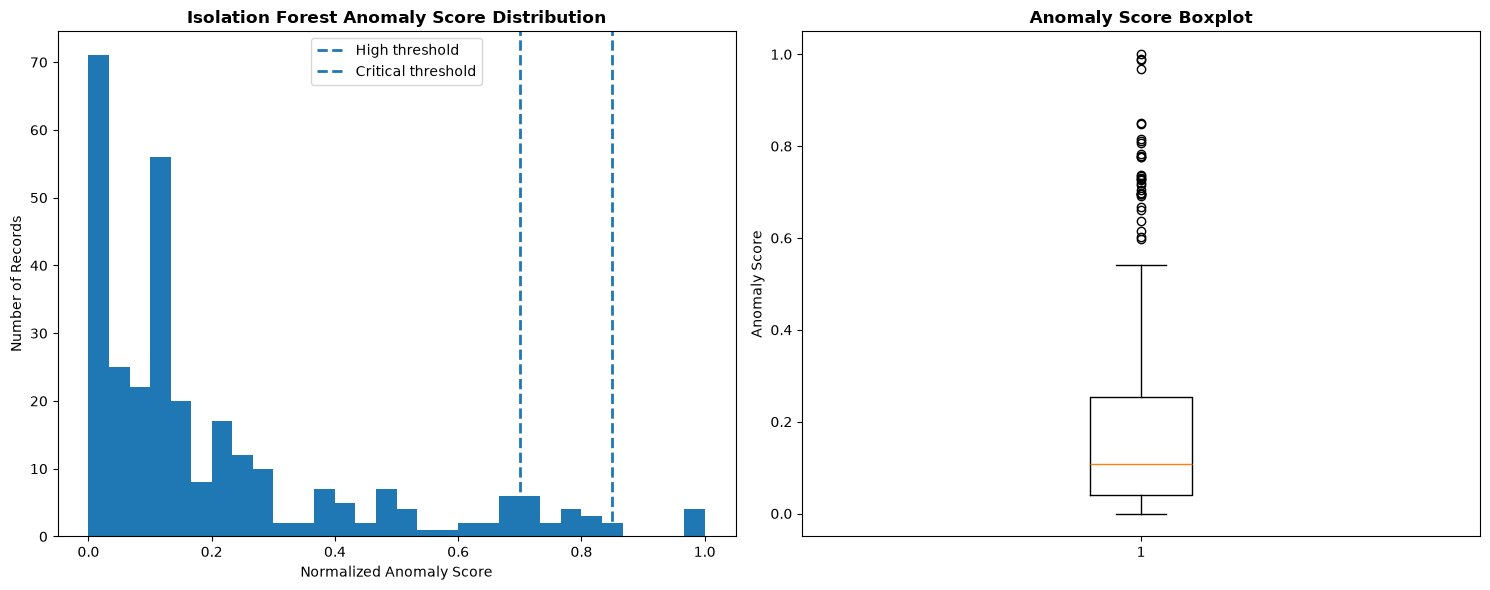

Saved figure: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_figures\anomaly_score_distribution.png


In [12]:
# ============================================================
# ANOMALY SCORE DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------

axes[0].hist(
    df["ml_anomaly_score"],
    bins=30
)

axes[0].axvline(
    0.70,
    linestyle="--",
    linewidth=2,
    label="High threshold"
)

axes[0].axvline(
    0.85,
    linestyle="--",
    linewidth=2,
    label="Critical threshold"
)

axes[0].set_title(
    "Isolation Forest Anomaly Score Distribution",
    fontweight="bold"
)

axes[0].set_xlabel(
    "Normalized Anomaly Score"
)

axes[0].set_ylabel(
    "Number of Records"
)

axes[0].legend()

# ------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------

axes[1].boxplot(
    df["ml_anomaly_score"],
    vert=True
)

axes[1].set_title(
    "Anomaly Score Boxplot",
    fontweight="bold"
)

axes[1].set_ylabel(
    "Anomaly Score"
)

plt.tight_layout()

figure_path = (
    FIGURE_OUTPUT_DIR
    / "anomaly_score_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {figure_path}"
)

## 4. Explainable Anomaly Analysis

The model identifies unusual observations, but a production-oriented risk system must also explain *why* an observation deserves attention. We therefore combine the ML anomaly score with independently engineered business signals.

In [13]:
# ============================================================
# EXPLAINABLE ANOMALY REASONS
# ============================================================

def generate_anomaly_reasons(
    row: pd.Series
) -> str:

    reasons = []

    # Price
    if (
        "price_iqr_outlier" in row.index
        and row["price_iqr_outlier"] == 1
    ):
        reasons.append(
            "statistical price outlier"
        )

    if (
        "price_deviation_pct" in row.index
        and pd.notna(row["price_deviation_pct"])
        and abs(row["price_deviation_pct"]) >= 30
    ):
        direction = (
            "above"
            if row["price_deviation_pct"] > 0
            else "below"
        )

        reasons.append(
            f"price {direction} median by "
            f"{abs(row['price_deviation_pct']):.1f}%"
        )

    # Availability
    if (
        row.get(
            "availability_state",
            "unknown"
        )
        in ["out_of_stock", "low_stock"]
    ):
        reasons.append(
            "availability risk signal"
        )

    # NLP disruption
    if (
        row.get(
            "disruption_signal_flag",
            0
        ) == 1
    ):
        reasons.append(
            "supply-chain disruption language"
        )

    # Negative signal
    if (
        row.get(
            "negative_signal_flag",
            0
        ) == 1
    ):
        reasons.append(
            "negative market/review language"
        )

    # Counterfeit
    if (
        row.get(
            "counterfeit_signal_flag",
            0
        ) == 1
    ):
        reasons.append(
            "counterfeit-related language"
        )

    # Supplier
    if (
        row.get(
            "supplier_disruption_frequency",
            0
        ) >= 0.5
    ):
        reasons.append(
            "elevated supplier disruption frequency"
        )

    # Data quality
    if (
        row.get(
            "record_completeness_score",
            1
        ) < 0.50
    ):
        reasons.append(
            "low record completeness"
        )

    if not reasons:
        reasons.append(
            "multivariate behaviour isolated by ML model"
        )

    return "; ".join(reasons)


df["anomaly_reasons"] = df.apply(
    generate_anomaly_reasons,
    axis=1
)

explainable_anomalies = (
    df[
        df["ml_anomaly_label"] == 1
    ]
    .sort_values(
        "ml_anomaly_score",
        ascending=False
    )
)

display(
    explainable_anomalies[
        [
            column
            for column in [
                "record_id",
                "source",
                "product",
                "company",
                "supplier",
                "price",
                "availability_state",
                "ml_anomaly_score_100",
                "anomaly_severity",
                "anomaly_reasons"
            ]
            if column in df.columns
        ]
    ].head(30)
)

,record_id,source,product,company,supplier,price,availability_state,ml_anomaly_score_100,anomaly_severity,anomaly_reasons
127,SS-000128,TradeIndia,Allenger Altima F100 Fixed Cath Lab Machine,Rentomed,NaN,"15,340,000.0000",other,100.0000,CRITICAL,statistical price outlier; price above median ...
99,SS-000100,TradeIndia,Siemens Artis Zee Cath Lab,Arihant Medmach Private Limited,NaN,"14,000,000.0000",other,99.0400,CRITICAL,statistical price outlier; price above median ...
5,SS-000006,DeoDap,Leak Proof Tape – Instant Waterproof Seal for ...,BoltForce,NaN,102.0000,unknown,98.6900,CRITICAL,price below median by 89.3%
238,SS-000239,TradeIndia,Cath Lab Machine,Mf India,NaN,"15,000,000.0000",other,96.7100,CRITICAL,statistical price outlier; price above median ...
4,SS-000005,DeoDap,Electric Drill Machine – Compact & Powerful 28...,DeoDap,NaN,1.0000,unknown,85.0000,CRITICAL,price below median by 99.9%
8,SS-000009,DeoDap,Hardware Tool Set – 11 Pcs Multi-Functional Kit,BoltForce,NaN,207.0000,unknown,84.8000,HIGH,price below median by 78.2%
167,SS-000168,TradeIndia,Broken Bag Detector,Toshbro Controls Pvt. Ltd.,NaN,950.0000,other,81.4900,HIGH,negative market/review language; low record co...
11,SS-000012,DeoDap,Manual Wall Fastening Nail Gun Tool for Wood a...,DeoDap,NaN,400.0000,unknown,81.1100,HIGH,price below median by 57.9%
2,SS-000003,DeoDap,Manual Wall Fastening Nail Gun Tool Set (1 Set),DeoDap,NaN,375.0000,unknown,80.7400,HIGH,price below median by 60.5%
42,SS-000043,TradeIndia,Broken Bag Detector,Applied Techno Engineers Private Limited,NaN,"58,000.0000",other,78.2900,HIGH,statistical price outlier; price above median ...


In [14]:
# ============================================================
# TOP ANOMALOUS OBSERVATIONS
# ============================================================

top_anomalies = (
    df
    .sort_values(
        "ml_anomaly_score",
        ascending=False
    )
    .head(25)
    .copy()
)

ANOMALY_DISPLAY_COLUMNS = [
    "record_id",
    "source",
    "title",
    "company",
    "supplier",
    "product",
    "price",
    "availability_state",
    "text_risk_score",
    "preliminary_risk_score",
    "ml_anomaly_score_100",
    "anomaly_severity",
    "anomaly_reasons",
]

ANOMALY_DISPLAY_COLUMNS = [
    column
    for column in ANOMALY_DISPLAY_COLUMNS
    if column in top_anomalies.columns
]

display(
    top_anomalies[
        ANOMALY_DISPLAY_COLUMNS
    ]
)

,record_id,source,title,company,supplier,product,price,availability_state,text_risk_score,preliminary_risk_score,ml_anomaly_score_100,anomaly_severity,anomaly_reasons
127,SS-000128,TradeIndia,Allenger Altima F100 Fixed Cath Lab Machine,Rentomed,NaN,Allenger Altima F100 Fixed Cath Lab Machine,"15,340,000.0000",other,0.0000,44.4200,100.0000,CRITICAL,statistical price outlier; price above median ...
99,SS-000100,TradeIndia,Siemens Artis Zee Cath Lab - Application: Hosp...,Arihant Medmach Private Limited,NaN,Siemens Artis Zee Cath Lab,"14,000,000.0000",other,0.0000,44.4200,99.0400,CRITICAL,statistical price outlier; price above median ...
5,SS-000006,DeoDap,Leak Proof Tape – Instant Waterproof Seal for ...,BoltForce,NaN,Leak Proof Tape – Instant Waterproof Seal for ...,102.0000,unknown,0.0000,17.1600,98.6900,CRITICAL,price below median by 89.3%
238,SS-000239,TradeIndia,Cath Lab Machine,Mf India,NaN,Cath Lab Machine,"15,000,000.0000",other,0.0000,44.4200,96.7100,CRITICAL,statistical price outlier; price above median ...
4,SS-000005,DeoDap,Electric Drill Machine – Compact & Powerful 28...,DeoDap,NaN,Electric Drill Machine – Compact & Powerful 28...,1.0000,unknown,0.0000,14.7400,85.0000,CRITICAL,price below median by 99.9%
8,SS-000009,DeoDap,Hardware Tool Set – 11 Pcs Multi-Functional Ki...,BoltForce,NaN,Hardware Tool Set – 11 Pcs Multi-Functional Kit,207.0000,unknown,0.0000,16.0900,84.8000,HIGH,price below median by 78.2%
167,SS-000168,TradeIndia,Broken Bag Detector,Toshbro Controls Pvt. Ltd.,NaN,Broken Bag Detector,950.0000,other,0.0500,19.8500,81.4900,HIGH,negative market/review language; low record co...
11,SS-000012,DeoDap,Manual Wall Fastening Nail Gun Tool for Wood a...,DeoDap,NaN,Manual Wall Fastening Nail Gun Tool for Wood a...,400.0000,unknown,0.0000,14.4300,81.1100,HIGH,price below median by 57.9%
2,SS-000003,DeoDap,Manual Wall Fastening Nail Gun Tool Set (1 Set),DeoDap,NaN,Manual Wall Fastening Nail Gun Tool Set (1 Set),375.0000,unknown,0.0000,14.6300,80.7400,HIGH,price below median by 60.5%
42,SS-000043,TradeIndia,Broken Bag Detector - Accuracy: +2 %,Applied Techno Engineers Private Limited,NaN,Broken Bag Detector,"58,000.0000",other,0.0500,45.6700,78.2900,HIGH,statistical price outlier; price above median ...


In [15]:
# ============================================================
# SOURCE-LEVEL ANOMALY ANALYSIS
# ============================================================

source_anomaly_analysis = (
    df
    .groupby(
        "source",
        dropna=False
    )
    .agg(
        records=(
            "record_id",
            "count"
        ),
        anomalies=(
            "ml_anomaly_label",
            "sum"
        ),
        mean_anomaly_score=(
            "ml_anomaly_score",
            "mean"
        ),
        maximum_anomaly_score=(
            "ml_anomaly_score",
            "max"
        ),
    )
    .reset_index()
)

source_anomaly_analysis[
    "anomaly_rate"
] = (
    source_anomaly_analysis["anomalies"]
    /
    source_anomaly_analysis["records"]
)

source_anomaly_analysis[
    "anomaly_rate_pct"
] = (
    source_anomaly_analysis["anomaly_rate"]
    * 100
).round(2)

source_anomaly_analysis[
    "mean_anomaly_score_100"
] = (
    source_anomaly_analysis["mean_anomaly_score"]
    * 100
).round(2)

source_anomaly_analysis[
    "maximum_anomaly_score_100"
] = (
    source_anomaly_analysis["maximum_anomaly_score"]
    * 100
).round(2)

display(
    source_anomaly_analysis
    .sort_values(
        "anomaly_rate",
        ascending=False
    )
)

,source,records,anomalies,mean_anomaly_score,maximum_anomaly_score,anomaly_rate,anomaly_rate_pct,mean_anomaly_score_100,maximum_anomaly_score_100
0,DeoDap,16,8,0.7624,0.9869,0.5000,50.0000,76.2400,98.6900
2,TradeIndia,247,7,0.1258,1.0000,0.0283,2.8300,12.5800,100.0000
1,Meesho,40,1,0.4466,0.7791,0.0250,2.5000,44.6600,77.9100


In [16]:
# ============================================================
# SUPPLIER ANOMALY PROFILING
# ============================================================

if "supplier" in df.columns:

    supplier_anomaly_analysis = (
        df
        .groupby(
            "supplier",
            dropna=False
        )
        .agg(
            records=(
                "record_id",
                "count"
            ),
            anomalies=(
                "ml_anomaly_label",
                "sum"
            ),
            average_anomaly_score=(
                "ml_anomaly_score",
                "mean"
            ),
            maximum_anomaly_score=(
                "ml_anomaly_score",
                "max"
            ),
            average_risk_score=(
                "preliminary_risk_score",
                "mean"
            ),
        )
        .reset_index()
    )

    supplier_anomaly_analysis[
        "anomaly_rate_pct"
    ] = (
        supplier_anomaly_analysis["anomalies"]
        /
        supplier_anomaly_analysis["records"]
        * 100
    ).round(2)

    supplier_anomaly_analysis[
        "average_anomaly_score_100"
    ] = (
        supplier_anomaly_analysis[
            "average_anomaly_score"
        ]
        * 100
    ).round(2)

    supplier_anomaly_analysis[
        "maximum_anomaly_score_100"
    ] = (
        supplier_anomaly_analysis[
            "maximum_anomaly_score"
        ]
        * 100
    ).round(2)

    # Require at least two observations to reduce
    # misleading one-record supplier rankings.
    supplier_anomaly_analysis = (
        supplier_anomaly_analysis[
            supplier_anomaly_analysis["records"] >= 2
        ]
        .sort_values(
            [
                "anomaly_rate_pct",
                "average_anomaly_score_100"
            ],
            ascending=False
        )
    )

    print(
        "Supplier anomaly profile "
        "(minimum 2 observations):"
    )

    display(
        supplier_anomaly_analysis.head(25)
    )

else:

    supplier_anomaly_analysis = pd.DataFrame()

    print(
        "Supplier field not available."
    )

Supplier anomaly profile (minimum 2 observations):


,supplier,records,anomalies,average_anomaly_score,maximum_anomaly_score,average_risk_score,anomaly_rate_pct,average_anomaly_score_100,maximum_anomaly_score_100
0,NaN,303,16,0.2017,1.0000,23.5173,5.2800,20.1700,100.0000


In [17]:
# ============================================================
# PRODUCT ANOMALY PROFILING
# ============================================================

if "product" in df.columns:

    product_anomaly_analysis = (
        df
        .groupby(
            "product",
            dropna=False
        )
        .agg(
            records=(
                "record_id",
                "count"
            ),
            anomalies=(
                "ml_anomaly_label",
                "sum"
            ),
            average_anomaly_score=(
                "ml_anomaly_score",
                "mean"
            ),
            maximum_anomaly_score=(
                "ml_anomaly_score",
                "max"
            ),
            average_price=(
                "price",
                "mean"
            ),
        )
        .reset_index()
    )

    product_anomaly_analysis[
        "anomaly_rate_pct"
    ] = (
        product_anomaly_analysis["anomalies"]
        /
        product_anomaly_analysis["records"]
        * 100
    ).round(2)

    product_anomaly_analysis[
        "average_anomaly_score_100"
    ] = (
        product_anomaly_analysis[
            "average_anomaly_score"
        ]
        * 100
    ).round(2)

    product_anomaly_analysis[
        "maximum_anomaly_score_100"
    ] = (
        product_anomaly_analysis[
            "maximum_anomaly_score"
        ]
        * 100
    ).round(2)

    product_anomaly_analysis = (
        product_anomaly_analysis[
            product_anomaly_analysis["records"] >= 2
        ]
        .sort_values(
            [
                "anomaly_rate_pct",
                "average_anomaly_score_100"
            ],
            ascending=False
        )
    )

    display(
        product_anomaly_analysis.head(25)
    )

else:

    product_anomaly_analysis = pd.DataFrame()

,product,records,anomalies,average_anomaly_score,maximum_anomaly_score,average_price,anomaly_rate_pct,average_anomaly_score_100,maximum_anomaly_score_100
50,Broken Bag Detector,3,3,0.7912,0.8149,"34,650.0000",100.0000,79.1200,81.4900
222,Siemens Artis Zee Cath Lab,2,1,0.5486,0.9904,"7,000,475.0000",50.0000,54.8600,99.0400
22,Air Slide,2,0,0.2629,0.3890,"20,500.0000",0.0000,26.2900,38.9000
133,Hydraulic Pallet Truck,2,0,0.2082,0.2228,"20,480.0000",0.0000,20.8200,22.2800
97,Fruit Hardness Tester,2,0,0.1745,0.1813,"31,225.0000",0.0000,17.4500,18.1300
21,Air Pump,2,0,0.1303,0.1536,"12,775.0000",0.0000,13.0300,15.3600
206,Powder Coating Fluidized Sheet,2,0,0.1069,0.1069,950.0000,0.0000,10.6900,10.6900
67,Crane Cable Trolley,2,0,0.0998,0.1067,774.5000,0.0000,9.9800,10.6700
227,Simple Auxanometer,3,0,0.0745,0.1069,916.6667,0.0000,7.4500,10.6900
91,Ethylene Glycol Monostearate,2,0,0.0733,0.0817,142.5000,0.0000,7.3300,8.1700


## 5. Model Diagnostics and Sensitivity Analysis

Unsupervised anomaly detection does not have a conventional accuracy score without verified labels. We therefore examine anomaly-rate stability and sensitivity to the contamination parameter.

In [18]:
# ============================================================
# CONTAMINATION SENSITIVITY ANALYSIS
# ============================================================

CONTAMINATION_VALUES = [
    0.02,
    0.03,
    0.05,
    0.07,
    0.10,
]

sensitivity_results = []

for contamination in CONTAMINATION_VALUES:

    model = IsolationForest(
        n_estimators=300,
        max_samples="auto",
        contamination=contamination,
        max_features=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    model.fit(
        X_model_processed
    )

    predictions = model.predict(
        X_model_processed
    )

    decision_scores = model.decision_function(
        X_model_processed
    )

    anomaly_rate = (
        predictions == -1
    ).mean()

    sensitivity_results.append({
        "contamination_parameter": contamination,
        "detected_anomalies": int(
            (predictions == -1).sum()
        ),
        "observed_anomaly_rate": anomaly_rate,
        "mean_decision_score": decision_scores.mean(),
        "minimum_decision_score": decision_scores.min(),
        "maximum_decision_score": decision_scores.max(),
    })

sensitivity_df = pd.DataFrame(
    sensitivity_results
)

sensitivity_df[
    "observed_anomaly_rate_pct"
] = (
    sensitivity_df[
        "observed_anomaly_rate"
    ]
    * 100
).round(2)

display(
    sensitivity_df
)

,contamination_parameter,detected_anomalies,observed_anomaly_rate,mean_decision_score,minimum_decision_score,maximum_decision_score,observed_anomaly_rate_pct
0,0.0200,7,0.0231,0.2274,-0.0712,0.3037,2.3100
1,0.0300,10,0.0330,0.2206,-0.0781,0.2969,3.3000
2,0.0500,16,0.0528,0.1982,-0.1005,0.2745,5.2800
3,0.0700,22,0.0726,0.1876,-0.1111,0.2638,7.2600
4,0.1000,31,0.1023,0.1502,-0.1485,0.2264,10.2300


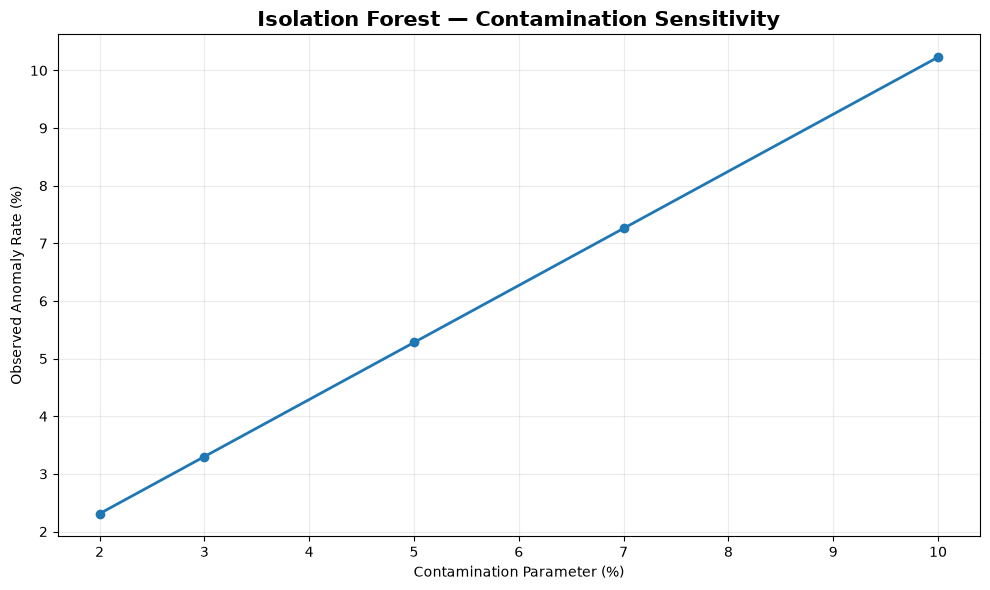

Saved figure: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_figures\contamination_sensitivity.png


In [19]:
# ============================================================
# CONTAMINATION SENSITIVITY VISUALIZATION
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    sensitivity_df[
        "contamination_parameter"
    ] * 100,
    sensitivity_df[
        "observed_anomaly_rate_pct"
    ],
    marker="o",
    linewidth=2,
)

ax.set_title(
    "Isolation Forest — Contamination Sensitivity",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Contamination Parameter (%)"
)

ax.set_ylabel(
    "Observed Anomaly Rate (%)"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

figure_path = (
    FIGURE_OUTPUT_DIR
    / "contamination_sensitivity.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {figure_path}"
)

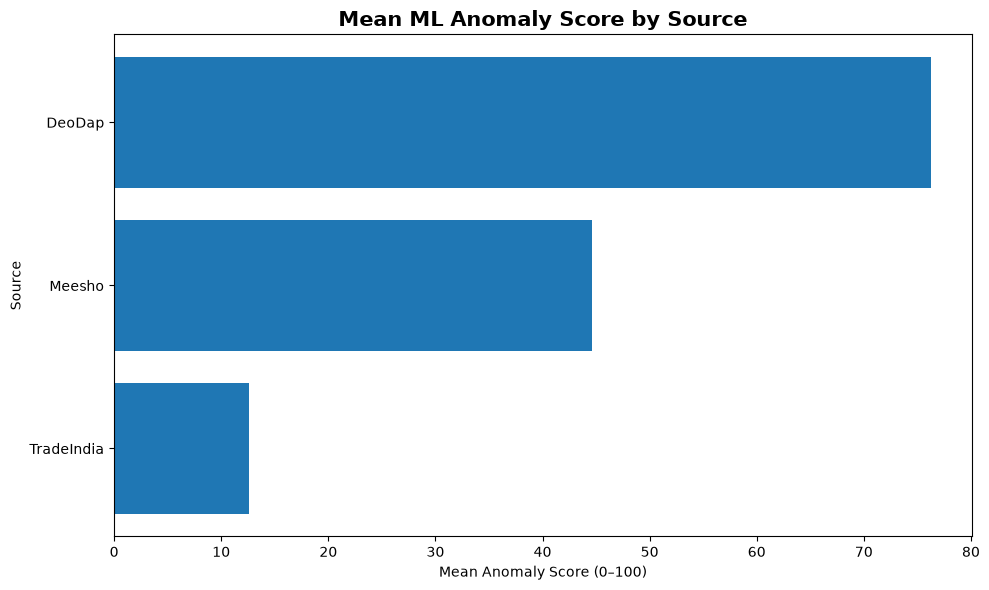

Saved figure: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_figures\source_anomaly_scores.png


In [20]:
# ============================================================
# SOURCE-LEVEL ANOMALY SCORE VISUALIZATION
# ============================================================

plot_source = (
    source_anomaly_analysis
    .sort_values(
        "mean_anomaly_score_100",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    plot_source["source"].astype(str),
    plot_source["mean_anomaly_score_100"]
)

ax.set_title(
    "Mean ML Anomaly Score by Source",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Mean Anomaly Score (0–100)"
)

ax.set_ylabel(
    "Source"
)

plt.tight_layout()

figure_path = (
    FIGURE_OUTPUT_DIR
    / "source_anomaly_scores.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {figure_path}"
)

## 6. Model Stability

A useful anomaly detector should not change completely when the random seed changes. We therefore compare the overlap of the highest-ranked anomalies across multiple model seeds.

In [21]:
# ============================================================
# MODEL STABILITY ANALYSIS
# ============================================================

STABILITY_SEEDS = [
    7,
    21,
    42,
    84,
    168,
]

TOP_K = min(
    20,
    len(df)
)

stability_rankings = {}

for seed in STABILITY_SEEDS:

    stability_model = IsolationForest(
        n_estimators=300,
        max_samples="auto",
        contamination=CONTAMINATION,
        max_features=1.0,
        random_state=seed,
        n_jobs=-1,
    )

    stability_model.fit(
        X_model_processed
    )

    seed_scores = (
        stability_model
        .decision_function(
            X_model_processed
        )
    )

    # Smaller decision function = more anomalous
    top_indices = np.argsort(
        seed_scores
    )[:TOP_K]

    stability_rankings[seed] = set(
        df.iloc[
            top_indices
        ]["record_id"]
    )

# Pairwise Jaccard similarity
stability_pairs = []

for i, seed_a in enumerate(
    STABILITY_SEEDS
):

    for seed_b in STABILITY_SEEDS[i + 1:]:

        set_a = stability_rankings[seed_a]
        set_b = stability_rankings[seed_b]

        intersection = len(
            set_a & set_b
        )

        union = len(
            set_a | set_b
        )

        jaccard = (
            intersection / union
            if union
            else 0
        )

        stability_pairs.append({
            "seed_a": seed_a,
            "seed_b": seed_b,
            "top_k": TOP_K,
            "jaccard_similarity": jaccard,
        })

stability_df = pd.DataFrame(
    stability_pairs
)

print("=" * 80)
print("MODEL STABILITY")
print("=" * 80)

display(
    stability_df
)

print(
    "\nMean top-K Jaccard similarity:",
    round(
        stability_df[
            "jaccard_similarity"
        ].mean(),
        4
    )
)

MODEL STABILITY


,seed_a,seed_b,top_k,jaccard_similarity
0,7,21,20,0.7391
1,7,42,20,0.8182
2,7,84,20,0.9048
3,7,168,20,0.8182
4,21,42,20,0.9048
5,21,84,20,0.8182
6,21,168,20,0.8182
7,42,84,20,0.9048
8,42,168,20,0.9048
9,84,168,20,0.9048



Mean top-K Jaccard similarity: 0.8536


In [22]:
# ============================================================
# FEATURE SENSITIVITY ANALYSIS
# ============================================================

BASELINE_ANOMALY_SCORE = (
    df["ml_anomaly_score"]
    .mean()
)

rng = np.random.default_rng(
    RANDOM_STATE
)

feature_sensitivity_results = []

# Use a subset of features to keep computation reasonable.
SENSITIVITY_FEATURES = MODEL_FEATURES.copy()

for feature_index, feature in enumerate(
    SENSITIVITY_FEATURES
):

    X_permuted = X_model_processed.copy()

    # Randomly permute one processed feature
    X_permuted[:, feature_index] = (
        rng.permutation(
            X_permuted[:, feature_index]
        )
    )

    permuted_decision = (
        isolation_forest
        .decision_function(
            X_permuted
        )
    )

    # Convert to anomaly direction
    permuted_score = (
        1
        -
        (
            permuted_decision
            - raw_decision_scores.min()
        )
        /
        (
            raw_decision_scores.max()
            - raw_decision_scores.min()
        )
    )

    permuted_score = np.clip(
        permuted_score,
        0,
        1
    )

    mean_change = abs(
        permuted_score.mean()
        -
        BASELINE_ANOMALY_SCORE
    )

    feature_sensitivity_results.append({
        "feature": feature,
        "mean_anomaly_score_change": mean_change,
    })

feature_sensitivity_df = (
    pd.DataFrame(
        feature_sensitivity_results
    )
    .sort_values(
        "mean_anomaly_score_change",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    feature_sensitivity_df.head(20)
)

,feature,mean_anomaly_score_change
0,preliminary_risk_score,0.0246
1,preliminary_risk_signal,0.0231
2,price_percentile,0.0178
3,price_zscore,0.0151
4,price_robust_zscore,0.0144
5,price_deviation_pct,0.0138
6,price,0.0127
7,price_iqr_outlier,0.0121
8,supplier_price_deviation_pct,0.0111
9,price_log,0.0110


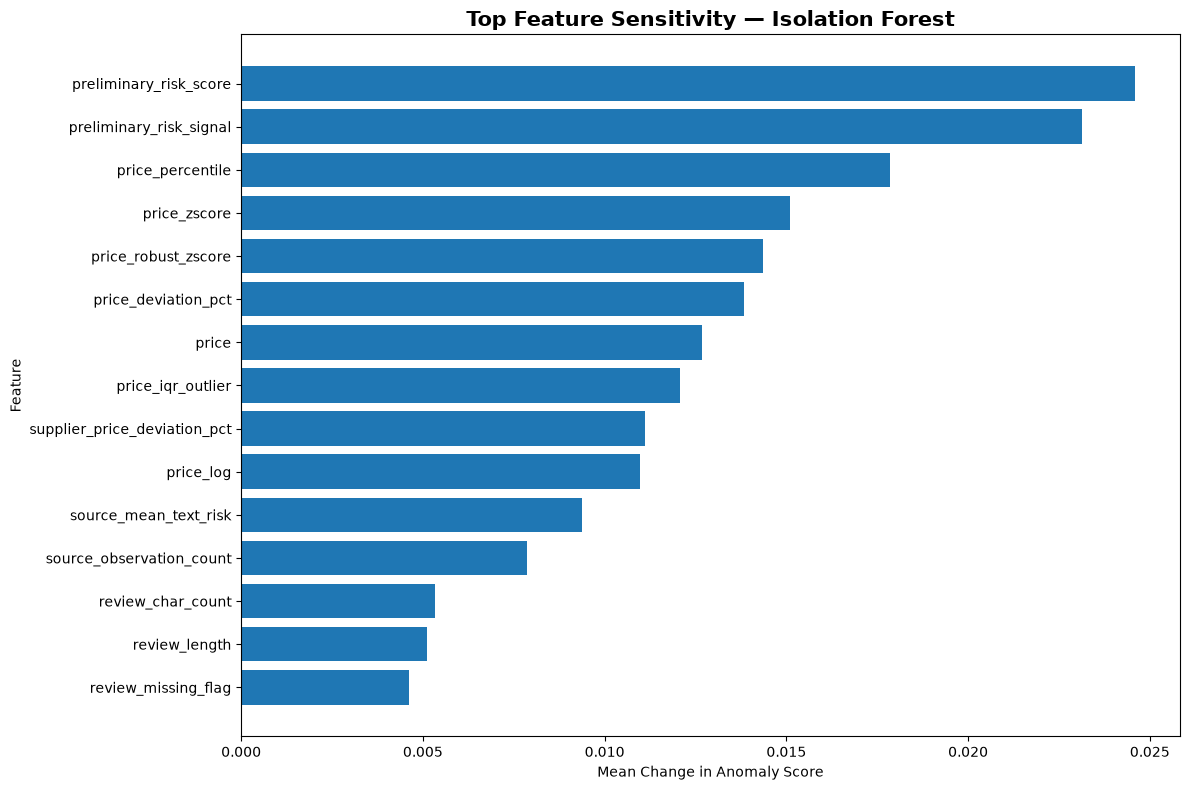

Saved figure: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_figures\feature_sensitivity.png


In [23]:
# ============================================================
# FEATURE SENSITIVITY VISUALIZATION
# ============================================================

top_sensitive = (
    feature_sensitivity_df
    .head(15)
    .sort_values(
        "mean_anomaly_score_change"
    )
)

fig, ax = plt.subplots(
    figsize=(12, 8)
)

ax.barh(
    top_sensitive["feature"],
    top_sensitive[
        "mean_anomaly_score_change"
    ]
)

ax.set_title(
    "Top Feature Sensitivity — Isolation Forest",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Mean Change in Anomaly Score"
)

ax.set_ylabel(
    "Feature"
)

plt.tight_layout()

figure_path = (
    FIGURE_OUTPUT_DIR
    / "feature_sensitivity.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {figure_path}"
)

## 7. Persist the ML Model and Predictions

The trained model, preprocessing pipeline, feature definitions, anomaly predictions, and diagnostic tables are saved as reusable artifacts for the downstream risk engine and Streamlit dashboard.

In [24]:
# ============================================================
# SAVE MODEL ARTIFACTS
# ============================================================

MODEL_PATH = (
    MODEL_OUTPUT_DIR
    / "supplyshield_isolation_forest.joblib"
)

PREPROCESSOR_PATH = (
    MODEL_OUTPUT_DIR
    / "supplyshield_anomaly_preprocessor.joblib"
)

FEATURES_PATH = (
    MODEL_OUTPUT_DIR
    / "supplyshield_anomaly_features.json"
)

MODEL_METADATA_PATH = (
    MODEL_OUTPUT_DIR
    / "isolation_forest_metadata.json"
)

# Save model
joblib.dump(
    isolation_forest,
    MODEL_PATH
)

# Save preprocessing
joblib.dump(
    model_preprocessor,
    PREPROCESSOR_PATH
)

# Save feature definitions
with open(
    FEATURES_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        MODEL_FEATURES,
        file,
        indent=2
    )

# Metadata
model_metadata = {
    "model": "IsolationForest",
    "purpose": "Supply-chain anomaly detection",
    "random_state": RANDOM_STATE,
    "n_estimators": isolation_forest.n_estimators,
    "contamination": CONTAMINATION,
    "max_samples": isolation_forest.max_samples,
    "max_features": isolation_forest.max_features,
    "training_rows": int(len(df)),
    "training_features": int(len(MODEL_FEATURES)),
    "anomaly_count": int(
        df["ml_anomaly_label"].sum()
    ),
    "anomaly_rate": float(
        df["ml_anomaly_label"].mean()
    ),
}

with open(
    MODEL_METADATA_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        model_metadata,
        file,
        indent=4
    )

print("=" * 80)
print("MODEL ARTIFACTS SAVED")
print("=" * 80)

print("Model:")
print(MODEL_PATH)

print("\nPreprocessor:")
print(PREPROCESSOR_PATH)

print("\nFeature definition:")
print(FEATURES_PATH)

print("\nMetadata:")
print(MODEL_METADATA_PATH)

MODEL ARTIFACTS SAVED
Model:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\models\supplyshield_isolation_forest.joblib

Preprocessor:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\models\supplyshield_anomaly_preprocessor.joblib

Feature definition:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\models\supplyshield_anomaly_features.json

Metadata:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\models\isolation_forest_metadata.json


In [25]:
# ============================================================
# SAVE ANOMALY PREDICTIONS
# ============================================================

PREDICTION_COLUMNS = [
    "record_id",
    "source",
    "title",
    "company",
    "supplier",
    "product",
    "price",
    "currency",
    "availability",
    "availability_state",
    "rating",
    "review",
    "url",
    "ml_anomaly_decision",
    "ml_anomaly_score",
    "ml_anomaly_score_100",
    "ml_anomaly_label",
    "anomaly_severity",
    "anomaly_reasons",
    "preliminary_risk_score",
    "preliminary_risk_band",
]

PREDICTION_COLUMNS = [
    column
    for column in PREDICTION_COLUMNS
    if column in df.columns
]

anomaly_predictions = df[
    PREDICTION_COLUMNS
].copy()

PREDICTIONS_PATH = (
    ML_OUTPUT_DIR
    / "anomaly_predictions.csv"
)

anomaly_predictions.to_csv(
    PREDICTIONS_PATH,
    index=False,
    encoding="utf-8"
)

print(
    f"Predictions saved to:\n{PREDICTIONS_PATH}"
)

print(
    f"\nRows saved: {len(anomaly_predictions):,}"
)

Predictions saved to:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_results\anomaly_predictions.csv

Rows saved: 303


In [26]:
# ============================================================
# SAVE DIAGNOSTIC TABLES
# ============================================================

OUTPUT_TABLES = {
    "severity_distribution.csv":
        severity_distribution,

    "source_anomaly_analysis.csv":
        source_anomaly_analysis,

    "sensitivity_analysis.csv":
        sensitivity_df,

    "model_stability.csv":
        stability_df,

    "feature_sensitivity.csv":
        feature_sensitivity_df,
}

if not supplier_anomaly_analysis.empty:
    OUTPUT_TABLES[
        "supplier_anomaly_analysis.csv"
    ] = supplier_anomaly_analysis

if not product_anomaly_analysis.empty:
    OUTPUT_TABLES[
        "product_anomaly_analysis.csv"
    ] = product_anomaly_analysis


for filename, table in OUTPUT_TABLES.items():

    output_path = (
        ML_OUTPUT_DIR
        / filename
    )

    table.to_csv(
        output_path,
        index=False
    )

    print(
        f"Saved: {output_path}"
    )

Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_results\severity_distribution.csv
Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_results\source_anomaly_analysis.csv
Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_results\sensitivity_analysis.csv
Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_results\model_stability.csv
Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_results\feature_sensitivity.csv
Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_results\supplier_anomaly_analysis.csv
Saved: C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_results\product_anomaly_analysis.csv


In [27]:
# ============================================================
# FINAL ML PIPELINE VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("SUPPLYSHIELD AI — ANOMALY DETECTION VALIDATION")
print("=" * 80)

validation_checks = {
    "Dataset loaded":
        len(df) > 0,

    "ML feature matrix created":
        X_model_processed.shape[0] == len(df),

    "No NaN in processed matrix":
        not np.isnan(X_model_processed).any(),

    "No infinite values":
        not np.isinf(X_model_processed).any(),

    "Isolation Forest trained":
        hasattr(
            isolation_forest,
            "estimators_"
        ),

    "Anomaly scores generated":
        "ml_anomaly_score" in df.columns,

    "Anomaly labels generated":
        "ml_anomaly_label" in df.columns,

    "Explainable reasons generated":
        "anomaly_reasons" in df.columns,

    "Model artifact exists":
        MODEL_PATH.exists(),

    "Prediction artifact exists":
        PREDICTIONS_PATH.exists(),
}

for check, status in validation_checks.items():

    print(
        f"[{'PASS' if status else 'FAIL':<4}] {check}"
    )

failed_checks = [
    check
    for check, status in validation_checks.items()
    if not status
]

print("-" * 80)

if failed_checks:

    print("ML PIPELINE VALIDATION FAILED")

    for check in failed_checks:
        print(f" - {check}")

    raise RuntimeError(
        "One or more ML validation checks failed."
    )

else:

    print(
        "ALL ML VALIDATION CHECKS PASSED."
    )

print("-" * 80)

print(
    f"\nRecords analyzed       : {len(df):,}"
)

print(
    f"Features used          : {len(MODEL_FEATURES):,}"
)

print(
    f"Detected anomalies     : "
    f"{int(df['ml_anomaly_label'].sum()):,}"
)

print(
    f"Detected anomaly rate  : "
    f"{df['ml_anomaly_label'].mean():.2%}"
)

print(
    f"\nModel artifact:\n{MODEL_PATH}"
)

print(
    f"\nPrediction artifact:\n{PREDICTIONS_PATH}"
)

print(
    "\nREADY FOR NLP RISK ENGINE + RISK SCORING."
)


SUPPLYSHIELD AI — ANOMALY DETECTION VALIDATION
[PASS] Dataset loaded
[PASS] ML feature matrix created
[PASS] No NaN in processed matrix
[PASS] No infinite values
[PASS] Isolation Forest trained
[PASS] Anomaly scores generated
[PASS] Anomaly labels generated
[PASS] Explainable reasons generated
[PASS] Model artifact exists
[PASS] Prediction artifact exists
--------------------------------------------------------------------------------
ALL ML VALIDATION CHECKS PASSED.
--------------------------------------------------------------------------------

Records analyzed       : 303
Features used          : 33
Detected anomalies     : 16
Detected anomaly rate  : 5.28%

Model artifact:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\models\supplyshield_isolation_forest.joblib

Prediction artifact:
C:\Users\Pradeep Bhat\Documents\Hackathons\SupplyShield-AI\member2\outputs\ml_results\anomaly_predictions.csv

READY FOR NLP RISK ENGINE + RISK SCORING.


## Anomaly Detection Complete

The SupplyShield anomaly-detection layer now produces:

- Multivariate anomaly scores
- Anomaly labels
- Severity levels
- Explainable anomaly reasons
- Source-level anomaly statistics
- Supplier-level anomaly profiles
- Product-level anomaly profiles
- Contamination sensitivity diagnostics
- Model stability diagnostics
- Feature sensitivity diagnostics
- A persisted Isolation Forest model
- Reusable anomaly predictions

These outputs will be consumed by the NLP risk engine and final SupplyShield risk-scoring layer.